## 3DoF Quadrotor SCP

Imports

In [1]:
# Basic imports
import importlib
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Trajopt imports --> pip install -e ~/ACL/trajopt
import trajopt; importlib.reload(trajopt)
import trajopt.core.modules.method.scp as scp
import trajopt.core.problem as prob
import trajopt.utils.config_loader as cfg
import trajopt.utils.tools as tools
import trajopt.analysis.default_analysis as default_analysis
import trajopt.analysis.statistics as stats

from trajopt.analysis.trajplots import *
import copy

setup problem and run SCP

In [2]:
from typing import Any

def add_monte_carlo_dispersions(mission_dict, realization):
    for mc_var, mc_disp in realization.items():
        mission_dict[mc_var] = mission_dict[mc_var] + mc_disp

gen_mc_variations    = 1
save_mc_variations   = 1
save_scenario_data   = 1

example_name = "quadrotor_3dof"
mc_name = "mc1"
scenario_data_name = example_name

nominal_config  = cfg.load_configs(example_name)

mv_variations = cfg.load_mv_variations(example_name)

if gen_mc_variations:
    mc_variations = cfg.gen_mc_variations(example_name)

    if save_mc_variations:
        np.save(f"data/mc_variations/{mc_name}", mc_variations)
else:
    mc_variations = np.load(f"data/mc_variations/{mc_name}.npy", allow_pickle=True).item()

variations = {
    "method": mv_variations,
    "mission": mc_variations
}

scenario_data = {}

# loop through method variations
for name, method_variation in variations["method"].items():
    
    # initialize method sub-dictionary for scenario_data dict
    scenario_data[name] = {"method_params": {},
                                  'mc_data': [None] * (variations["mission"]["num_variations"] + 1),
                                  }

    cached_subprob = None
    
    # loop through monte-carlo mission parameter realizations (number of runs)
    for run_idx, realization in enumerate(variations["mission"]["realizations"]):
        
        # take in nominal configs
        run_config = copy.deepcopy(nominal_config)

        # set method variations
        run_config["method"] = tools.deep_update(run_config["method"], method_variation)

        # set monte carlo mission variations
        add_monte_carlo_dispersions(run_config["mission"], realization)

        # create problem instance
        problem = prob.Problem(run_config, cached_subprob)
        
        # run SCP
        problem = scp.run_scp(problem)

        # perform default analysis on this mc run and store related params
        scenario_data[name]["mc_data"][run_idx] = default_analysis.perform_default_analysis(problem)

        # # store total time for scp (used to calculate time to converge)
        # scenario_data[name]['mc_data'][run_idx] = problem.solution['t_all']
        
        # cache subproblem graph to speed up solves
        cached_subprob = None # problem.method.subprob

if save_scenario_data:
    np.save(f"data/scenario_data/{scenario_data_name}_{mc_name}", scenario_data)

scales: 
d: 10.0000, t: 1.0000, m: 1.0000, v: 10.0000, a: 10.0000, f: 10.0000, ang: 57.2958, angv: 57.2958
Initial guess time: 0.11846787494141608 seconds
--------------------------------------------------------------------------------------------------------------------------------------------------------
                                              ..:: quadrotor: PTR with Virtual Buffer ::..
--------------------------------------------------------------------------------------------------------------------------------------------------------
  Iteration |  Propagation |   Solve   |    Parse   |  log(dz)  |      log(VB)    |   log(VB)   |  log(VB)    | Solve status |  Time of    |   Cost    
            |   time [ms]  | time [ms] |  time [ms] |           |  (path + NFZ)   |  (terminal) |  (dynamics) |              |  Flight [s] |           
------------------------------------------------------------------------------------------------------------------------------------------------

/Users/dan/miniconda3/envs/numpy2env/lib/python3.13/site-packages/cvxpy/reductions/solvers/solving_chain_utils.py:41: UserWarning: The problem has an expression with dimension greater than 2. Defaulting to the SCIPY backend for canonicalization.
  warnings.warn(UserWarning(


     01     |    00309.1   |   0008.7  |   3116.9   |   -1.2    |      -12.0      |    -00.4    |     -12.0   |    optimal    |   1.00   |  459.5
     02     |    00003.0   |   0010.0  |   0000.8   |   -0.5    |      -12.0      |    -00.5    |     -12.0   |    optimal    |   1.99   |  564.4
     03     |    00002.6   |   0008.5  |   0000.7   |   -0.1    |      -12.0      |    -00.1    |     -12.0   |    optimal    |   6.23   |  2188.9
     04     |    00002.6   |   0009.1  |   0000.8   |   -0.1    |      -12.0      |    -02.4    |     -12.0   |    optimal    |   7.02   |  561.6
     05     |    00002.6   |   0009.9  |   0000.8   |   -0.7    |      -12.0      |    -02.1    |     -12.0   |    optimal    |   6.10   |  632.8
     06     |    00002.5   |   0009.6  |   0000.7   |   -0.7    |      -12.0      |    -02.0    |     -12.0   |    optimal    |   5.95   |  673.6
     07     |    00002.6   |   0009.4  |   0000.7   |   -0.7    |      -12.0      |    -01.8    |     -12.0   |    optimal 

perform default analysis and store in plot_sctruct for Dan


In [21]:
temp = scenario_data['method1']['mc_data'][0]['iters'][-1] # print(list(temp['weights'])) # print(len(temp))
# for t in list(temp)[0:20]:print(t)
problem.indices.constraints.nonlinear_inequality
data = {'scenario1':scenario_data}

# file path if you wish to save LaTeX tables (eg. path to a data/statistics/mc1_stats.txt)
file = None # example: ~/acl-link/prototypes/trajopt/src/trajopt/examples/quadrotor_3dof/data/stats/mc1_stats.txt
# generate and print statistics and associated tables
# analysis = stats.analyze_quality_metrics(scenario_data, filename=file)

# params_nominal  = scenario_data["method1"]['mc_data'][0]["params"]
# iters_nominal   = scenario_data["method1"]['mc_data'][0]["iters"]
# data = {};
# data = {'scenario1': scenario_data}
# # print(list(data['scenario1']['method1']['mc_data']));
# iter_data_final = iters_nominal[-1]
# z_nl = iter_data_final['z_nl']

In [28]:
PLTS1 = SCVXPLOTS(data);
PLTS1.setCurrent({'scenarios':['scenario1'],'methods':['method1','method2'],
                  'runs':[0,1,2,3,4,5],'iters':list(range(1000))})
def testFunc1(x,y): return np.sin(x[0]);
def testFunc2(x,y): return np.cos(x[0]);
def testFunc3(x,y): return np.sin(x[1]);
tag1 = 'testfunc1'; func_args = [{'val':'z_nl'},{'val':'z_nl'}];
tag2 = 'testfunc2'; func_args = [{'val':'z_nl'},{'val':'z_nl'}];
tag3 = 'testfunc3'; func_args = [{'val':'z_nl'},{'val':'z_nl'}];
PLTS1.calcField(tag1,testFunc1,func_ins = func_args)
PLTS1.calcField(tag2,testFunc2,func_ins = func_args)
PLTS1.calcField(tag3,testFunc3,func_ins = func_args)

# New Plots

In [10]:

PENS = {};
# PENS['z'] = {'frgba':[0,0,0,0.1],'lrgba':[0,0,0,0.1],'lw':2,'ls':'-','msty':'','msz':4};
PENS['init'] = {'frgba':[.0,.0,.0,.1],'lrgba':[.0,.0,.0,1.],'lw':1,'ls':'--','msty':'' ,'msz':3};
PENS['itr']  = {'frgba':[.0,.0,.0,.1],'lrgba':[.0,.0,1.,.2],'lw':1,'ls':'--','msty':'' ,'msz':3};
PENS['opt']  = {'frgba':[.0,.0,.0,.1],'lrgba':[.0,.0,1.,1.],'lw':1,'ls':''  ,'msty':'o','msz':3};
PENS['prop'] = {'frgba':[.0,.0,.0,.1],'lrgba':[1.,.0,.0,1.],'lw':1,'ls':'-' ,'msty':'' ,'msz':3};
PENS['ref']  = {'frgba':[.0,.0,.0,.1],'lrgba':[.0,.0,.0,1.],'lw':1,'ls':'--','msty':'*','msz':3};


# Fig.5 Bank Angle vs. Time

<>:18: SyntaxWarning: invalid escape sequence '\p'
<>:18: SyntaxWarning: invalid escape sequence '\p'
/var/folders/9h/62cp03kd3gv3jr3ny97ftngr0000gn/T/ipykernel_36976/3337494257.py:18: SyntaxWarning: invalid escape sequence '\p'
  ylabels[1] = 'Heading $\psi$ [deg]';


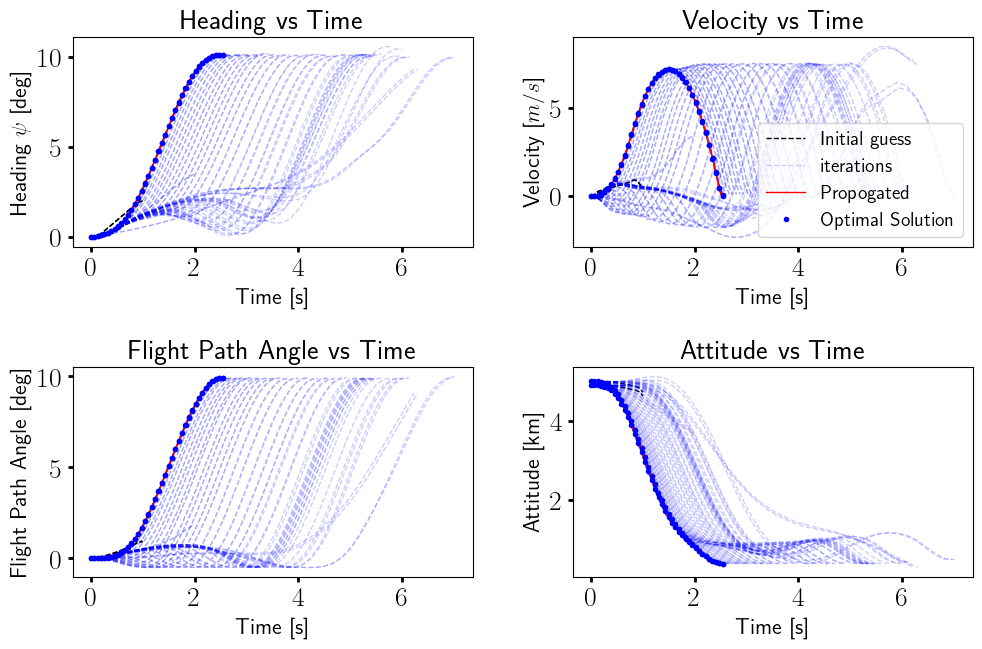

In [11]:
# grid = PLTS1.specGrid(typ='2x2'); 
fig = plt.figure(figsize=(10,6));
grid = {};
grid[(1,0)] = [0.55,0.05,0.4,0.35]; grid[(1,1)] = [0.55,0.6,0.4,0.35];
grid[(0,0)] = [0.05,0.05,0.4,0.35]; grid[(0,1)] = [0.05,0.6,0.4,0.35];
axs = PLTS1.createGrid(fig,grid = grid);

state_plot_inds = {0:(0,0),1:(0,1),2:(1,0),3:(1,1)};
state_names = {0:'x-position',1:'y-position',2:'x-velocity',3:'y-velocity'};

titles = {}; ylabels = {};
titles[0] = 'Flight Path Angle vs Time';
titles[1] = 'Heading vs Time';
titles[2] = 'Attitude vs Time';
titles[3] = 'Velocity vs Time';

ylabels[0] = 'Flight Path Angle [deg]';
ylabels[1] = 'Heading $\psi$ [deg]';
ylabels[2] = 'Attitude [km]';
ylabels[3] = 'Velocity [$m/s$]';


itrs_all = list(range(1000))[2:]; runs = [0,1,2,3,4]; state_inds = [0,1,2,3];
for sind in state_inds:
    ax = axs[state_plot_inds[sind]];
    PLTS1.setCurrent({'scenarios':['scenario1'],'methods':['method1'],'runs':runs})

    params1 = {'label':'Initial guess','x':'t','y':('z',sind),'iters':[1],'legend':sind,};
    params2 = {'label':'iterations','x':'t','y':('z',sind),'iters':itrs_all,'legend':sind};
    params3 = {'label':'Propogated','x':'t_nl','y':('z_nl',sind),'iters':[-1],'legend':sind};
    params4 = {'label':'Optimal Solution','x':'t','y':('z',sind),'iters':[-1],'legend':sind};

    PLTS1.addPlot2D(ax,pen=PENS['init'],ins=params1);
    PLTS1.addPlot2D(ax,pen=PENS['itr'] ,ins=params2);
    PLTS1.addPlot2D(ax,pen=PENS['prop'],ins=params3); 
    PLTS1.addPlot2D(ax,pen=PENS['opt'] ,ins=params4); 
    
    params = {};
    params['title'] = {'text':titles[sind],'fontsize':20}
    params['xlabel'] = {'label':'Time [s]','fontsize':16}
    params['ylabel'] = {'label':ylabels[sind],'fontsize':16}
    params['ticks'] = {'labelsize':20,'width':2};
    PLTS1.setParams(ax,params);
    if sind == 3: PLTS1.addLegend(ax,sind,ins={'fontsize':14,'loc':'best'});

# Fig.7  - Discrete Optimal Solution

<>:13: SyntaxWarning: invalid escape sequence '\p'
<>:13: SyntaxWarning: invalid escape sequence '\p'
/var/folders/9h/62cp03kd3gv3jr3ny97ftngr0000gn/T/ipykernel_36976/3785141566.py:13: SyntaxWarning: invalid escape sequence '\p'
  ylabels[1] = 'Heading $\psi$ [deg]';


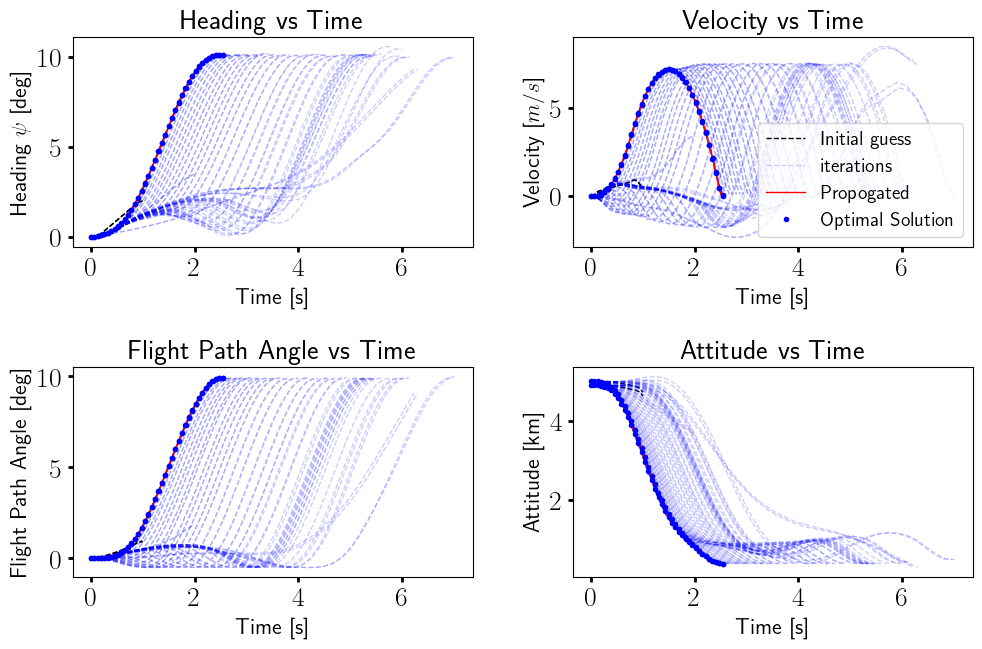

In [12]:
# grid = PLTS1.specGrid(typ='2x2'); 
## STATE PLOT OVER ITERATIONS ## STATE PLOT OVER ITERATIONS
state_plot_inds = {0:(0,0),1:(0,1),2:(1,0),3:(1,1)};
state_names = {0:'x-position',1:'y-position',2:'x-velocity',3:'y-velocity'};

titles = {}; ylabels = {};
titles[0] = 'Flight Path Angle vs Time';
titles[1] = 'Heading vs Time';
titles[2] = 'Attitude vs Time';
titles[3] = 'Velocity vs Time';

ylabels[0] = 'Flight Path Angle [deg]';
ylabels[1] = 'Heading $\psi$ [deg]';
ylabels[2] = 'Attitude [km]';
ylabels[3] = 'Velocity [$m/s$]';

fig = plt.figure(figsize=(10,6));
PLTS1 = SCVXPLOTS(data);
grid = {};
grid[(1,0)] = [0.55,0.05,0.4,0.35]; grid[(1,1)] = [0.55,0.6,0.4,0.35];
grid[(0,0)] = [0.05,0.05,0.4,0.35]; grid[(0,1)] = [0.05,0.6,0.4,0.35];
axs = PLTS1.createGrid(fig,grid = grid);

itrs_all = list(range(1000))[2:]; runs = [0,1,2,3,4]; state_inds = [0,1,2,3];
for sind in state_inds:
    ax = axs[state_plot_inds[sind]];
    PLTS1.setCurrent({'scenarios':['scenario1'],'methods':['method1'],'runs':runs})

    params1 = {'label':'Initial guess','x':'t','y':('z',sind),'iters':[1],'legend':sind,};
    params2 = {'label':'iterations','x':'t','y':('z',sind),'iters':itrs_all,'legend':sind};
    params3 = {'label':'Propogated','x':'t_nl','y':('z_nl',sind),'iters':[-1],'legend':sind};
    params4 = {'label':'Optimal Solution','x':'t','y':('z',sind),'iters':[-1],'legend':sind};

    PLTS1.addPlot2D(ax,pen=PENS['init'],ins=params1);
    PLTS1.addPlot2D(ax,pen=PENS['itr'] ,ins=params2);
    PLTS1.addPlot2D(ax,pen=PENS['prop'],ins=params3); 
    PLTS1.addPlot2D(ax,pen=PENS['opt'] ,ins=params4); 
    
    params = {};
    params['title'] = {'text':titles[sind],'fontsize':20}
    params['xlabel'] = {'label':'Time [s]','fontsize':16}
    params['ylabel'] = {'label':ylabels[sind],'fontsize':16}
    params['ticks'] = {'labelsize':20,'width':2};
    PLTS1.setParams(ax,params);
    if sind == 3: PLTS1.addLegend(ax,sind,ins={'fontsize':14,'loc':'best'});

# Fig. 8 - Path Constraints

# Fig. 9 - Penalty Weights for Constraints

# Fig.10 Convergence Behavior, Nondimensional constraint violation
### -- NEED TO ADD DATA TO STRUCT

# Fig.11 Penaly weights for constraints

# Fig.12 Bank Angle vs. Time 

# Fig. 13 Position Trajectories per method

# Fig. 14 State solutions per method

# Fig. 15 Path constraints by method

# Fig. 16 Cost convergence by method

# Fig. 17 Penalty weights for constraints

# Fig. 18 Convergence behavior

# Fig.19 Bank angle vs time and angle of attack vs. time

# Fig.20 Dispersion trajectories Auto-SCvx and PTR

# Fig.21 State trajetories dispersed across initial conditions Auto-SCvx and PTR

# Fig. 22 Path constraints initial guess dispersion

# Fig.23 Penalty weights for constraints

# Fig.24 Virtual buffer penalyt weights: terminal condition

# Fig.25 Cost convergence

# Fig.26 Convergence Behavior

# Fig.27 Longitude dispersion

# example plots#

NameError: name 'iters0' is not defined

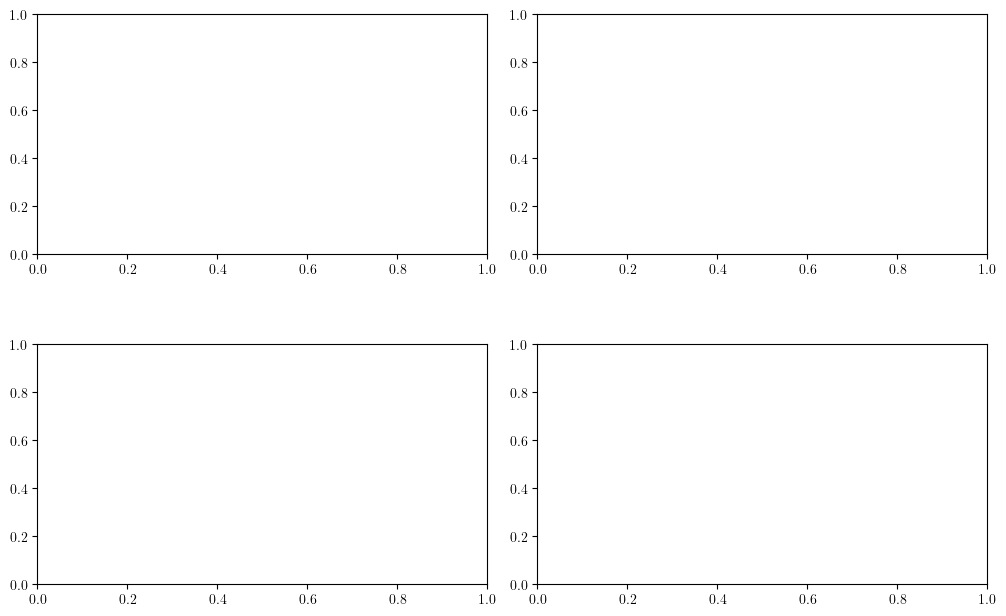

In [13]:
fig = plt.figure(figsize=(10,6));
PLTS1 = SCVXPLOTS(data);
grid = PLTS1.specGrid(typ='2x2');
axs = PLTS1.createGrid(fig,grid = grid);


## STATE PLOT OVER ITERATIONS ## STATE PLOT OVER ITERATIONS

sind = 0; pind = (0,0); ax = axs[pind];
state_plot_inds = {0:(0,0),1:(0,1),2:(1,0),3:(1,1)};

sinds = [0,1,2,3];
for sind in sinds:
    leg = sind;
    pind = state_plot_inds[sind]; ax = axs[pind];
    itr_tags1 = {'iters':iters0}; itr_tags2 = {'iters':[-1]};
    leg_tags = {'legend':leg,'label':'blarg'};

    PLTS1.addPlot2D(ax,pen=PENS['itr'],ins={**base_tags,**run_tags,**itr_tags1,**leg_tags,'label':'iters'+str(sind),'x':'t','y':('z',sind)});
    PLTS1.addPlot2D(ax,pen=PENS['nl'],ins={**base_tags,**run_tags,**itr_tags2,**leg_tags,'label':'nl'+str(sind),'x':'t_nl','y':('z_nl',sind)});
    PLTS1.addPlot2D(ax,pen=PENS['sub'],ins={**base_tags,**run_tags,**itr_tags2,**leg_tags,'label':'sub'+str(sind),'x':'t','y':('z',sind)});
    PLTS1.addPlot2D(ax,pen=PENS['ref'],ins={**base_tags,**run_tags,**itr_tags2,**leg_tags,'label':'ref'+str(sind),'x':'t_ref','y':('z_ref',sind)});

    xlabel = 'Time (s)'; ylabel='State z['+str(sind)+'] (units)';
    title = 'Trajectories OF State z['+str(sind)+'] over SCVX Iterations'
    PLTS1.addLegend(ax,leg,ins={'fontsize':14,'loc':'best'});
    PLTS1.setLabels(ax,xlabel=xlabel,ylabel=ylabel,ins={'fontsize':14});
    PLTS1.setTitle(ax,title=title,ins={'fontsize':16});      
    




# main plots

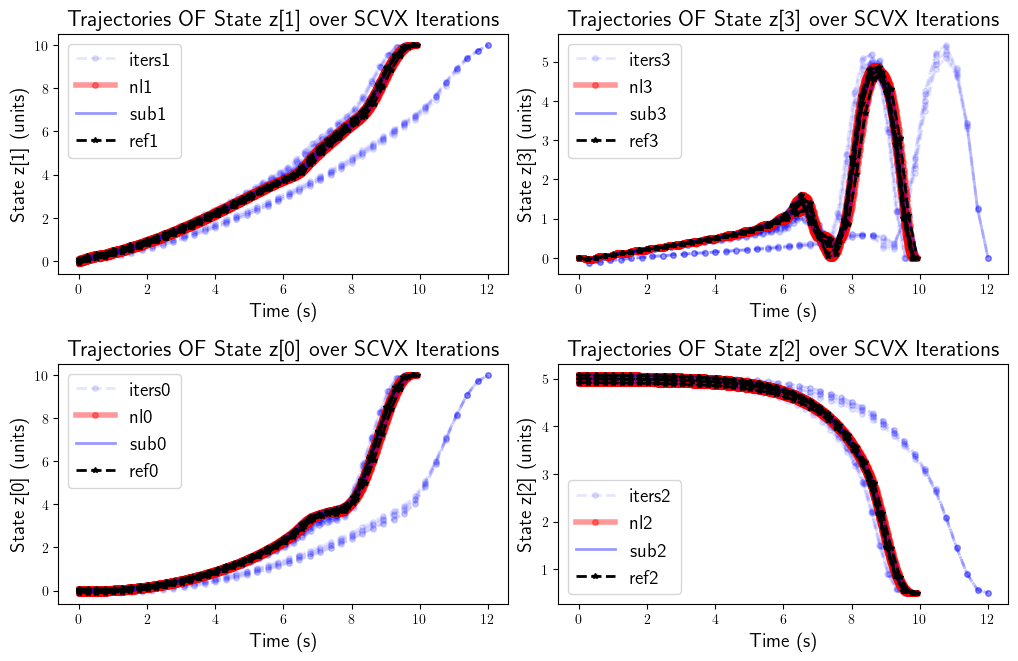

In [ ]:
fig = plt.figure(figsize=(10,6));
PLTS1 = SCVXPLOTS(data);
grid = PLTS1.specGrid(typ='2x2');
axs = PLTS1.createGrid(fig,grid = grid);

## STATE PLOT OVER ITERATIONS ## STATE PLOT OVER ITERATIONS
## STATE PLOT OVER ITERATIONS ## STATE PLOT OVER ITERATIONS

sind = 0; pind = (0,0); ax = axs[pind];
state_plot_inds = {0:(0,0),1:(0,1),2:(1,0),3:(1,1)};

sinds = [0,1,2,3];
for sind in sinds:
    leg = sind;
    pind = state_plot_inds[sind]; ax = axs[pind];
    itr_tags1 = {'iters':iters0}; itr_tags2 = {'iters':[-1]};
    leg_tags = {'legend':leg,'label':'blarg'};

    PLTS1.addPlot2D(ax,pen=PENS['itr'],ins={**base_tags,**run_tags,**itr_tags1,**leg_tags,'label':'iters'+str(sind),'x':'t','y':('z',sind)});
    PLTS1.addPlot2D(ax,pen=PENS['nl'],ins={**base_tags,**run_tags,**itr_tags2,**leg_tags,'label':'nl'+str(sind),'x':'t_nl','y':('z_nl',sind)});
    PLTS1.addPlot2D(ax,pen=PENS['sub'],ins={**base_tags,**run_tags,**itr_tags2,**leg_tags,'label':'sub'+str(sind),'x':'t','y':('z',sind)});
    PLTS1.addPlot2D(ax,pen=PENS['ref'],ins={**base_tags,**run_tags,**itr_tags2,**leg_tags,'label':'ref'+str(sind),'x':'t_ref','y':('z_ref',sind)});


    xlabel = 'Time (s)'; ylabel='State z['+str(sind)+'] (units)';
    title = 'Trajectories OF State z['+str(sind)+'] over SCVX Iterations'
    PLTS1.addLegend(ax,leg,ins={'fontsize':14,'loc':'best'});
    PLTS1.setLabels(ax,xlabel=xlabel,ylabel=ylabel,ins={'fontsize':14});
    PLTS1.setTitle(ax,title=title,ins={'fontsize':16});      
    




In [ ]:
# Basic imports
import importlib
import numpy as np
import matplotlib.pyplot as plt

# Trajopt imports --> pip install -e ~/ACL/trajopt
import trajopt; importlib.reload(trajopt)
import trajopt.core.modules.method.scp as scp
import trajopt.core.problem as prob
import trajopt.utils.config_loader as cfg
import trajopt.analysis.default_analysis as default_analysis
import trajopt.utils.tools as tools

from trajopt.analysis.trajplots import *
import copy

In [ ]:
from typing import Any

def add_monte_carlo_dispersions(mission_dict, realization):
    for mc_var, mc_disp in realization.items():
        mission_dict[mc_var] = mission_dict[mc_var] + mc_disp

gen_mc_variations    = 1
save_mc_variations   = 1
save_scenario_data   = 1

example_name = "quadrotor_3dof"
mc_name = "mc1"
scenario_data_name = example_name

nominal_config  = cfg.load_configs(example_name)

mv_variations = cfg.load_mv_variations(example_name)

if gen_mc_variations:
    mc_variations = cfg.gen_mc_variations(example_name)

    if save_mc_variations:
        np.save(f"data/mc_variations/{mc_name}", mc_variations)
else:
    mc_variations = np.load(f"data/mc_variations/{mc_name}.npy", allow_pickle=True).item()

variations = {
    "method": mv_variations,
    "mission": mc_variations
}

scenario_data = {}

# loop through method variations
for method_name, method_variation in variations["method"].items():
    
    # initialize method sub-dictionary for scenario_data dict
    scenario_data[method_name] = {"method_params": {},
                                  'mc_data': [None] * (variations["mission"]["num_variations"] + 1),
                                  }

    cached_subprob = None
    
    # loop through monte-carlo mission parameter realizations (number of runs)
    for run_idx, realization in enumerate(variations["mission"]["realizations"]):
        
        # take in nominal configs
        run_config = copy.deepcopy(nominal_config)

        # set method variations
        run_config["method"] = tools.deep_update(run_config["method"], method_variation)

        # set monte carlo mission variations
        add_monte_carlo_dispersions(run_config["mission"], realization)

        # create problem instance
        problem = prob.Problem(run_config, cached_subprob)
        
        # run SCP
        problem = scp.run_scp(problem)

        # perform default analysis on this mc run and store related params
        scenario_data[method_name]["mc_data"][run_idx] = default_analysis.perform_default_analysis(problem)
        
        # cache subproblem graph to speed up solves
        cached_subprob = None # problem.method.subprob

if save_scenario_data:
    np.save(f"data/scenario_data/{scenario_data_name}_{mc_name}", scenario_data)

scales: 
d: 10.0000, t: 1.0000, m: 1.0000, v: 10.0000, a: 10.0000, f: 10.0000, ang: 57.2958, angv: 57.2958
Initial guess time: 0.13187429204117507 seconds
--------------------------------------------------------------------------------------------------------------------------------------------------------
                                              ..:: quadrotor: PTR with Virtual Buffer ::..
--------------------------------------------------------------------------------------------------------------------------------------------------------
  Iteration |  Propagation |   Solve   |    Parse   |  log(dz)  |      log(VB)    |   log(VB)   |  log(VB)    | Solve status |  Time of    |   Cost    
            |   time [ms]  | time [ms] |  time [ms] |           |  (path + NFZ)   |  (terminal) |  (dynamics) |              |  Flight [s] |           
------------------------------------------------------------------------------------------------------------------------------------------------

/Users/dan/miniconda3/envs/numpy2env/lib/python3.13/site-packages/cvxpy/reductions/solvers/solving_chain_utils.py:41: UserWarning: The problem has an expression with dimension greater than 2. Defaulting to the SCIPY backend for canonicalization.
  warnings.warn(UserWarning(


     01     |    00365.4   |   0008.8  |   3411.1   |   -1.2    |      -12.0      |    -00.4    |     -12.0   |    optimal    |   1.00   |  459.5
     02     |    00003.4   |   0010.1  |   0000.8   |   -0.5    |      -12.0      |    -00.5    |     -12.0   |    optimal    |   1.99   |  564.4
     03     |    00002.4   |   0008.8  |   0000.7   |   -0.1    |      -12.0      |    -00.1    |     -12.0   |    optimal    |   6.23   |  2188.9
     04     |    00002.6   |   0009.2  |   0000.7   |   -0.1    |      -12.0      |    -02.4    |     -12.0   |    optimal    |   7.02   |  561.6
     05     |    00002.4   |   0009.9  |   0000.8   |   -0.7    |      -12.0      |    -02.1    |     -12.0   |    optimal    |   6.10   |  632.8
     06     |    00002.4   |   0010.5  |   0000.8   |   -0.7    |      -12.0      |    -02.0    |     -12.0   |    optimal    |   5.95   |  673.6
     07     |    00004.8   |   0009.8  |   0001.4   |   -0.7    |      -12.0      |    -01.8    |     -12.0   |    optimal 

old plotting code (feel free to delete and replace with new plotting code!)

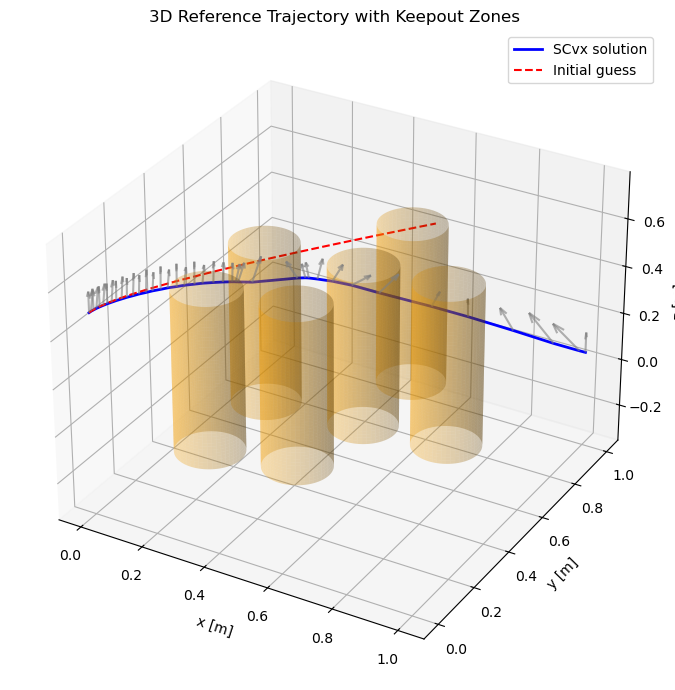

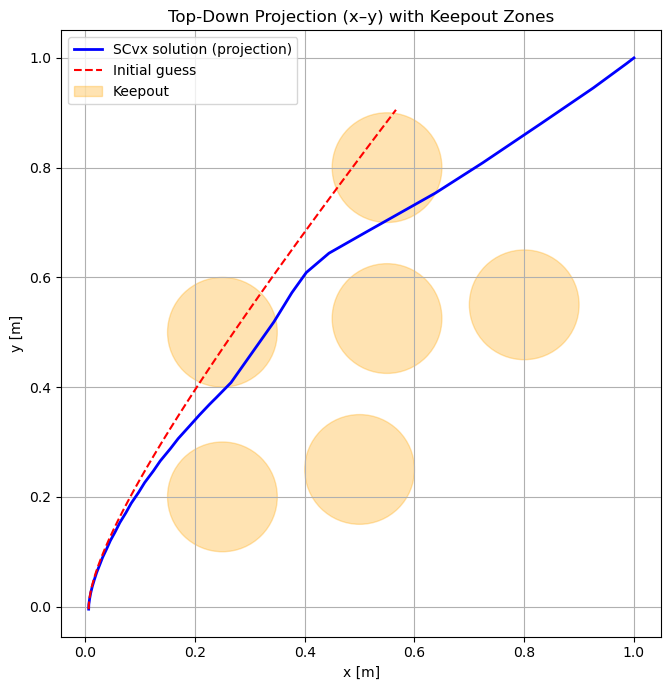

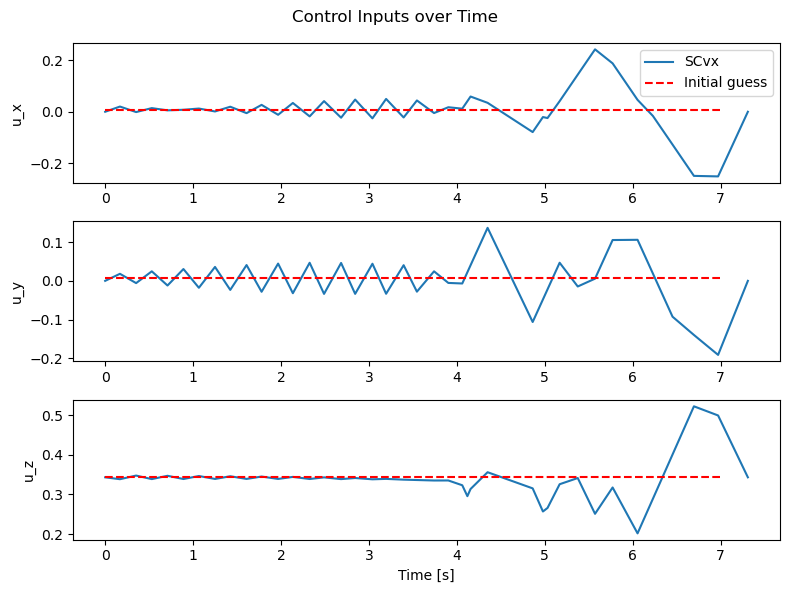

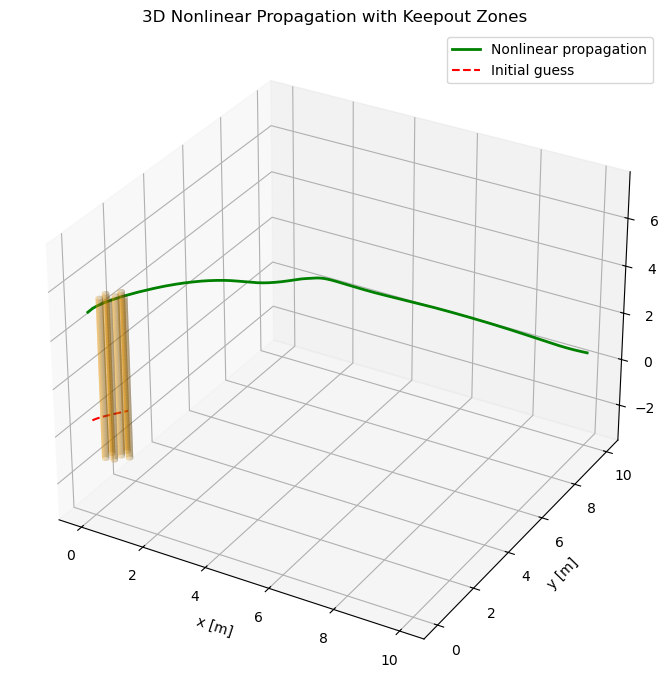

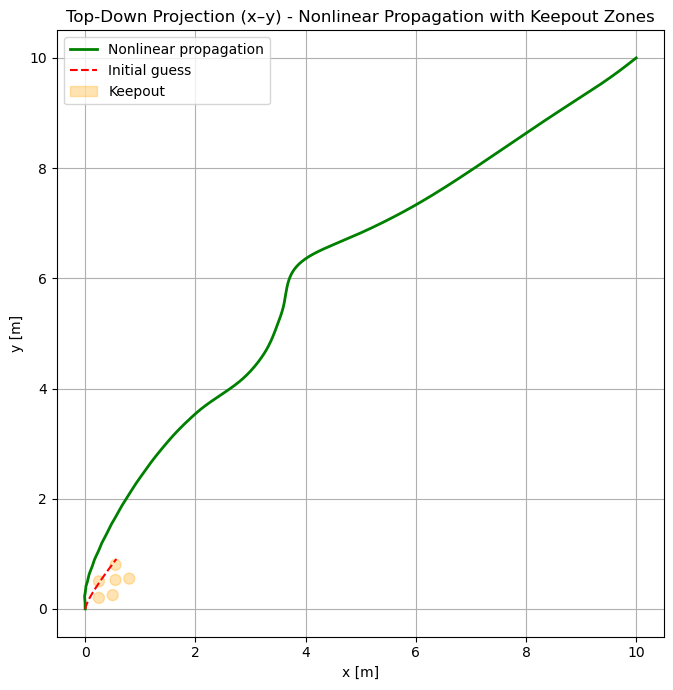

In [ ]:
# --- 3D Interactivity (run %matplotlib widget in Jupyter) ---
# run this once per notebook session
#%matplotlib widget

mission = problem.mission
model   = problem.model
method  = problem.method

# --- Retrieve trajectory and parameters ---

ts_init = method.ts_init
zs_init = method.zs_init
us_init = method.us_init
x_init  = zs_init[:, 0]
y_init  = zs_init[:, 1]
z_init  = zs_init[:, 2]

ts_opt  = problem.solution["ts"]
zs_opt  = problem.solution["zs"]
us_opt  = problem.solution["us"]

# ============================================================
# 3D Trajectory Plot (SCvx Solution)
# ============================================================
fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection="3d")

# --- Trajectories ---
ax.plot(zs_opt[:, 0], zs_opt[:, 1], zs_opt[:, 2],
        'b-', linewidth=2, label="SCvx solution")
ax.plot(x_init, y_init, z_init,
        'r--', linewidth=1.5, label="Initial guess")

# --- Thrust vectors (downsampled for clarity) ---
us_opt_scaled = 0.25 * us_opt
skip = max(1, len(zs_opt) // 25)
ax.quiver(
    zs_opt[::skip, 0], zs_opt[::skip, 1], zs_opt[::skip, 2],
    us_opt_scaled[::skip, 0], us_opt_scaled[::skip, 1], us_opt_scaled[::skip, 2],
    length=1.0, normalize=False, color='gray', alpha=0.6
)

# ============================================================
# Cylindrical Keepout Zones
# ============================================================
n_nfz = mission.n_nfz
z_traj_max = np.max(zs_opt[:, 2])
z_traj_min = np.min(zs_opt[:, 2])
height = (z_traj_max - z_traj_min) * 1.5  # cylinders taller than trajectory
z_bottom = z_traj_min - 0.25 * height
z_top = z_bottom + height

for i in range(n_nfz):
    xc = mission.obs['posc'][0, i]
    yc = mission.obs['posc'][1, i]
    rc = mission.obs['rc'][i]

    s = np.linspace(0, 2 * np.pi, 100)
    z = np.linspace(z_bottom, z_top, 50)
    S, Z = np.meshgrid(s, z)
    X = xc + rc * np.cos(S)
    Y = yc + rc * np.sin(S)
    ax.plot_surface(X, Y, Z, color='orange', alpha=0.3, linewidth=0, shade=True)

# ============================================================
# Equal Axis Scaling
# ============================================================
def set_axes_equal(ax):
    """Make 3D axes have equal scale."""
    x_limits = ax.get_xlim3d()
    y_limits = ax.get_ylim3d()
    z_limits = ax.get_zlim3d()
    x_range = abs(x_limits[1] - x_limits[0])
    y_range = abs(y_limits[1] - y_limits[0])
    z_range = abs(z_limits[1] - z_limits[0])
    max_range = max([x_range, y_range, z_range]) / 2.0
    mid_x = np.mean(x_limits)
    mid_y = np.mean(y_limits)
    mid_z = np.mean(z_limits)
    ax.set_xlim3d([mid_x - max_range, mid_x + max_range])
    ax.set_ylim3d([mid_y - max_range, mid_y + max_range])
    ax.set_zlim3d([mid_z - max_range, mid_z + max_range])

set_axes_equal(ax)

# --- Labels, Legend ---
ax.set_xlabel("x [m]")
ax.set_ylabel("y [m]")
ax.set_zlabel("z [m]")
ax.set_title("3D Reference Trajectory with Keepout Zones")
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

# ============================================================
# Top-Down Projection (x–y plane) - SCvx Solution
# ============================================================
fig, ax2d = plt.subplots(figsize=(7, 7))

# Plot trajectory footprints
ax2d.plot(zs_opt[:, 0], zs_opt[:, 1], 'b-', linewidth=2, label="SCvx solution (projection)")
ax2d.plot(x_init, y_init, 'r--', linewidth=1.5, label="Initial guess")

# Plot circular obstacle projections
for i in range(n_nfz):
    xc = mission.obs['posc'][0, i]
    yc = mission.obs['posc'][1, i]
    rc = mission.obs['rc'][i]
    circle = plt.Circle((xc, yc), rc, color='orange', alpha=0.3, label="Keepout" if i == 0 else None)
    ax2d.add_patch(circle)

ax2d.set_aspect('equal', adjustable='box')
ax2d.set_xlabel("x [m]")
ax2d.set_ylabel("y [m]")
ax2d.set_title("Top-Down Projection (x–y) with Keepout Zones")
ax2d.grid(True)
ax2d.legend()
plt.tight_layout()
plt.show()

# ============================================================
# 2D Control vs Time Plot
# ============================================================
fig = plt.figure(figsize=(8, 6))
ax_1 = fig.add_subplot(311)
ax_2 = fig.add_subplot(312)
ax_3 = fig.add_subplot(313)

ax_1.plot(ts_opt, us_opt[:, 0], label="SCvx")
ax_1.plot(ts_init, us_init[:, 0], 'r--', label="Initial guess")
ax_1.set_ylabel("u_x")

ax_2.plot(ts_opt, us_opt[:, 1])
ax_2.plot(ts_init, us_init[:, 1], 'r--')
ax_2.set_ylabel("u_y")

ax_3.plot(ts_opt, us_opt[:, 2])
ax_3.plot(ts_init, us_init[:, 2], 'r--')
ax_3.set_ylabel("u_z")
ax_3.set_xlabel("Time [s]")

ax_1.legend()
plt.suptitle("Control Inputs over Time")
plt.tight_layout()
plt.show()

# ============================================================
# 3D Nonlinear Propagation Plot
# ============================================================
fig_nl = plt.figure(figsize=(9, 7))
ax_nl = fig_nl.add_subplot(111, projection="3d")

# --- Nonlinear propagation trajectory ---
ax_nl.plot(z_nl[:, 0], z_nl[:, 1], z_nl[:, 2],
           'g-', linewidth=2, label="Nonlinear propagation")
ax_nl.plot(x_init, y_init, z_init,
           'r--', linewidth=1.5, label="Initial guess")

# ============================================================
# Cylindrical Keepout Zones (for nonlinear plot)
# ============================================================
z_traj_max_nl = np.max(z_nl[:, 2])
z_traj_min_nl = np.min(z_nl[:, 2])
height_nl = (z_traj_max_nl - z_traj_min_nl) * 1.5
z_bottom_nl = z_traj_min_nl - 0.25 * height_nl
z_top_nl = z_bottom_nl + height_nl

for i in range(n_nfz):
    xc = mission.obs['posc'][0, i]
    yc = mission.obs['posc'][1, i]
    rc = mission.obs['rc'][i]

    s = np.linspace(0, 2 * np.pi, 100)
    z = np.linspace(z_bottom_nl, z_top_nl, 50)
    S, Z = np.meshgrid(s, z)
    X = xc + rc * np.cos(S)
    Y = yc + rc * np.sin(S)
    ax_nl.plot_surface(X, Y, Z, color='orange', alpha=0.3, linewidth=0, shade=True)

# ============================================================
# Equal Axis Scaling (for nonlinear plot)
# ============================================================
set_axes_equal(ax_nl)

# --- Labels, Legend ---
ax_nl.set_xlabel("x [m]")
ax_nl.set_ylabel("y [m]")
ax_nl.set_zlabel("z [m]")
ax_nl.set_title("3D Nonlinear Propagation with Keepout Zones")
ax_nl.legend()
ax_nl.grid(True)
plt.tight_layout()
plt.show()

# ============================================================
# Top-Down Projection (x–y plane) - Nonlinear Propagation
# ============================================================
fig_nl_2d, ax2d_nl = plt.subplots(figsize=(7, 7))

# Plot nonlinear propagation footprint
ax2d_nl.plot(z_nl[:, 0], z_nl[:, 1], 'g-', linewidth=2, label="Nonlinear propagation")
ax2d_nl.plot(x_init, y_init, 'r--', linewidth=1.5, label="Initial guess")

# Plot circular obstacle projections
for i in range(n_nfz):
    xc = mission.obs['posc'][0, i]
    yc = mission.obs['posc'][1, i]
    rc = mission.obs['rc'][i]
    circle = plt.Circle((xc, yc), rc, color='orange', alpha=0.3, label="Keepout" if i == 0 else None)
    ax2d_nl.add_patch(circle)

ax2d_nl.set_aspect('equal', adjustable='box')
ax2d_nl.set_xlabel("x [m]")
ax2d_nl.set_ylabel("y [m]")
ax2d_nl.set_title("Top-Down Projection (x–y) - Nonlinear Propagation with Keepout Zones")
ax2d_nl.grid(True)
ax2d_nl.legend()
plt.tight_layout()
plt.show()